# Packages and dependancies

In [1]:
!pip install tensorflow
!pip install keras_tuner --upgrade
!pip install keras-metrics
!pip install scipy --upgrade
!pip install tensorboard --upgrade
!pip install scikit-learn
!pip install nltk
!pip install seaborn
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Imports

In [2]:
import pandas as pd
import numpy as np
import nltk
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, f1_score

from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import RandomSearch

# Downloadable Content

In [3]:
nltk.download("wordnet")
nltk.download("stopwords")
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\feras\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\feras\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\feras\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Fetch data from Dataset 

In [4]:
df = pd.read_csv('data/raw_data(in) (2).csv', encoding='latin-1')
print(df.head())

                                               Label  Disease  \
0                               ibastin, licorzide,         2   
1   buddine, cefchomy, physiological sodium chlor...        1   
2                           su huang akane capsule,         1   
3   levofloxacin, compound nailoxica beno capsule...        1   
4   pu di lan anti -inflammatory oral liquid, qui...        1   

                                     Original Dialog  
0       patients: i have not taken good skin care...  
1      patient: i feel uncomfortable from my thro...  
2      patient: if you have a cold, you do nt wa...  
3     patient: it has been a continuous low -feve...  
4     patients: flowing nose, throat, dry, headac...  


In [5]:
print(df['Disease'].value_counts())

Disease
1    1734
2    1400
3     547
4     519
6     249
5     221
7     152
Name: count, dtype: int64


# Undersamling The dataframes to balance the classes

In [6]:
# Calculate class distribution
counts = df['Disease'].value_counts()
print("Class distribution before balancing:")
print(counts)

Class distribution before balancing:
Disease
1    1734
2    1400
3     547
4     519
6     249
5     221
7     152
Name: count, dtype: int64


In [7]:
# Select the target count based on the smallest class
target_count = counts.min()

In [8]:
# Perform undersampling for each class
balanced_df = (
    df.groupby('Disease')  # Group by the 'Disease' column
    .apply(lambda x: x.sample(target_count, random_state=42))  # Randomly sample each group
    .reset_index(drop=True)  # Reset the index
)
print(balanced_df['Disease'].value_counts())
print(balanced_df.head)

Disease
1    152
2    152
3    152
4    152
5    152
6    152
7    152
Name: count, dtype: int64
<bound method NDFrame.head of                                                   Label  Disease  \
0      pu di lan anti -inflammatory oral liquid, ant...        1   
1                                               kuake,         1   
2                                           banlangen,         1   
3      tyno, cefchomy, licorice tablets, wind and co...        1   
4                                        levofloxacin,         1   
...                                                 ...      ...   
1059                                     erythromycin,         7   
1060          youmeishafen, compound nailing capsules,         7   
1061                        chuanbei loquat, cefchomy,         7   
1062   buddine, licorice tablets, compound nailing c...        7   
1063                        levofloxacin, meng lu ste,         7   

                                        Original Dialog 

C:\Users\feras\AppData\Local\Temp\ipykernel_9240\377804732.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(target_count, random_state=42))  # Randomly sample each group


In [9]:
balanced_counts = balanced_df['Disease'].value_counts().sample(frac=1, random_state=42)

# Print class distribution after balancing (in random order)
print("Class distribution after balancing (random order):")
print(balanced_counts)

Class distribution after balancing (random order):
Disease
1    152
2    152
6    152
3    152
5    152
4    152
7    152
Name: count, dtype: int64


# Natrual Language Preprocessing

In [10]:
tokenizer = nltk.RegexpTokenizer(r"[a-zA-Z]{3,}")  # استخراج الكلمات التي تحتوي على 3 أحرف أو أكثر
lemmatizer = WordNetLemmatizer()  # أداة لإرجاع الكلمات إلى صيغة الجذر
stop_words = stopwords.words('english')  # قائمة الكلمات الشائعة باللغة الإنجليزية

In [11]:
# دالة لتحويل النصوص إلى قائمة كلمات مفيدة
def dialog_to_processed_token_list(s):
    # استخراج الكلمات باستخدام الـ tokenizer
    tokens = tokenizer.tokenize(s)
    # تحويل الكلمات إلى حروف صغيرة
    loweredcase_tokens = [t.lower() for t in tokens]
    # إزالة الكلمات الشائعة
    useful_tokens = [t for t in loweredcase_tokens if t not in stop_words]
    # إرجاع الكلمات إلى صيغة الجذر
    lemmatized_tokens = [lemmatizer.lemmatize(t) for t in useful_tokens]
    return lemmatized_tokens

# تطبيق المعالجة على العمود "Original Dialog"
df['Processed Tokens'] = df['Original Dialog'].apply(dialog_to_processed_token_list)

# عرض النتيجة
print("Data after processing:")
print(df[['Original Dialog', 'Processed Tokens']].head())

Data after processing:
                                     Original Dialog  \
0       patients: i have not taken good skin care...   
1      patient: i feel uncomfortable from my thro...   
2      patient: if you have a cold, you do nt wa...   
3     patient: it has been a continuous low -feve...   
4     patients: flowing nose, throat, dry, headac...   

                                    Processed Tokens  
0  [patient, taken, good, skin, care, past, six, ...  
1  [patient, feel, uncomfortable, throat, night, ...  
2  [patient, cold, want, take, chinese, medicine,...  
3  [patient, continuous, low, fever, degree, thre...  
4  [patient, flowing, nose, throat, dry, headache...  


# Split the dataset into training and test dataframes

In [12]:
# Shuffle and split the dataset into training and test dataframes
def split_dataset(df):
    # Shuffle the dataset
    df = df.sample(frac=1, random_state=1)  # Ensure reproducibility with random_state
    df = df.reset_index(drop=True)  # Reset index after shuffling
    
    # Calculate the split index (80% for training, 20% for testing)
    split_index = int(len(df) * 0.8)
    
    # Split into training and testing dataframes
    train_df, test_df = df[:split_index], df[split_index:]
    
    # Reset index for both dataframes
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    return train_df, test_df

# تطبيق الدالة على الداتا الخاصة بمشروعك
train_df, test_df = split_dataset(df)

# عرض معلومات عن مجموعات البيانات الناتجة
print("Training DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)

# عرض أول صفين من بيانات التدريب
print("Sample from Training DataFrame:")
print(train_df.head())

# عرض أول صفين من بيانات الاختبار
print("Sample from Test DataFrame:")
print(test_df.head())


Training DataFrame shape: (3857, 4)
Test DataFrame shape: (965, 4)
Sample from Training DataFrame:
                                         Label  Disease  \
0         pudi lan batterflature oral liquid,         1   
1                             metharocopride ,        3   
2                     suhuang antipe capsule,         1   
3   pu di lan differential oral liquid, tyno,         1   
4                                 mino cytin,         2   

                                     Original Dialog  \
0    patient:1itching throat, sneezing, runny nos...   
1    patient: why do you feel that the stomach bl...   
2   patient: patients the day before yesterday, t...   
3   patient:i only eat the feeling of being cold ...   
4    patient: what to do with acne on the back re...   

                                    Processed Tokens  
0  [patient, itching, throat, sneezing, runny, no...  
1  [patient, feel, stomach, bloated, recently, fe...  
2  [patient, patient, day, yesterday, throat

In [13]:
# Dictionary to count the frequency of each token
token_counter = {}

In [14]:
# Iterate through each dialog in the training dataset
for dialog in train_df['Original Dialog']:
    # Convert the dialog into a list of processed tokens
    dialog_as_token_list = dialog_to_processed_token_list(dialog)

    # Increment the frequency of each token or add it to the dictionary
    for token in dialog_as_token_list:
        if token in token_counter:
            token_counter[token] += 1
        else:
            token_counter[token] = 1

# Print the type of token_counter and its content
print("Token counter type:", type(token_counter))
print("Token frequencies:")
print(token_counter)

Token counter type: <class 'dict'>
Token frequencies:
{'patient': 18003, 'itching': 480, 'throat': 1849, 'sneezing': 331, 'runny': 544, 'nose': 2268, 'doctor': 15880, 'hello': 2713, 'day': 2959, 'abnormal': 73, 'body': 812, 'temperature': 482, 'recently': 516, 'get': 345, 'worse': 32, 'swallowing': 56, 'sore': 465, 'nasal': 1057, 'congestion': 517, 'cough': 2445, 'sputum': 1357, 'give': 113, 'suggestion': 125, 'major': 15, 'problem': 518, 'recommended': 620, 'mask': 6165, 'feel': 1237, 'stomach': 1102, 'bloated': 27, 'hungry': 85, 'going': 224, 'bed': 85, 'nighti': 2, 'even': 50, 'sleep': 244, 'manifestation': 97, 'poor': 81, 'power': 19, 'time': 1454, 'morpholine': 5, 'disease': 375, 'several': 128, 'year': 1040, 'usually': 395, 'eat': 1790, 'less': 169, 'swell': 12, 'may': 541, 'gas': 23, 'insufficient': 20, 'increase': 64, 'exercise': 51, 'amount': 94, 'take': 2315, 'bite': 102, 'every': 348, 'night': 875, 'nightthen': 1, 'something': 175, 'spit': 74, 'breath': 78, 'comfortable': 95

In [15]:
# Function to check if a token's frequency exceeds a given threshold
def keep_token(processed_token, threshold):
    # Check if the token exists in token_counter
    if processed_token not in token_counter:
        return False
    else:
        # Return True if the frequency is above the threshold
        return token_counter[processed_token] > threshold


In [16]:
# Create a set to store the extracted features
features = set()

# Iterate over the tokens in token_counter
for token in token_counter:
    # Keep tokens that exceed the threshold (threshold = 3)
    if keep_token(token, 3):  # Threshold is set to 3
        features.add(token)

# Convert the set to a list
features = list(features)

# Print features before sorting
print("Model features Before sort=", features)

# Sort the features alphabetically
features.sort()

# Print features after sorting
print("Model features After sort=", features)

# Print the number of features extracted
print("Number of features extracted from the Dataset = ", len(features))


Model features Before sort= ['swelling', 'anyone', 'middle', 'tip', 'sebaceous', 'vomited', 'beforethe', 'doubt', 'continuously', 'moron', 'released', 'pale', 'noodle', 'swab', 'starting', 'rectal', 'possible', 'discharge', 'foot', 'kidney', 'expose', 'dream', 'home', 'twist', 'smooth', 'herpes', 'allergy', 'belly', 'suggestion', 'monitoring', 'hip', 'quantitative', 'folk', 'accurate', 'magnesium', 'bleed', 'result', 'anal', 'defecation', 'shooting', 'problem', 'bear', 'sweat', 'smart', 'however', 'raw', 'seems', 'meter', 'salon', 'efficiency', 'estimated', 'coffee', 'point', 'trust', 'getting', 'occasionally', 'particularly', 'affect', 'effect', 'squat', 'grain', 'environmental', 'hair', 'suggest', 'pierced', 'infant', 'urine', 'earring', 'external', 'sister', 'meal', 'well', 'usual', 'found', 'dandruff', 'lasting', 'anymore', 'basis', 'showed', 'yang', 'load', 'bath', 'fitness', 'moon', 'frequent', 'tongqiao', 'tonsillitis', 'line', 'transmitting', 'suffered', 'love', 'weighing', 'do

In [17]:
# Create a mapping from tokens to indices
token_to_index_mapping = {t: i for t, i in zip(features, range(len(features)))}

# Print the mapping
print("Token to Index Mapping:")
print(token_to_index_mapping)


Token to Index Mapping:
{'abdomen': 0, 'abdominal': 1, 'able': 2, 'abnormal': 3, 'abnormality': 4, 'abnormally': 5, 'abroad': 6, 'absorb': 7, 'absorbed': 8, 'absorption': 9, 'accessible': 10, 'accidentally': 11, 'accompanied': 12, 'according': 13, 'account': 14, 'accurate': 15, 'acetaminol': 16, 'acid': 17, 'acidic': 18, 'acidity': 19, 'acne': 20, 'acting': 21, 'active': 22, 'actively': 23, 'activity': 24, 'actual': 25, 'actually': 26, 'acupuncture': 27, 'acute': 28, 'ada': 29, 'add': 30, 'added': 31, 'adding': 32, 'addition': 33, 'adenoid': 34, 'adjust': 35, 'adjusted': 36, 'adjusting': 37, 'adjustment': 38, 'adolescence': 39, 'adult': 40, 'advance': 41, 'adverse': 42, 'affect': 43, 'affected': 44, 'affecting': 45, 'affordable': 46, 'afraid': 47, 'afternoon': 48, 'age': 49, 'agent': 50, 'aggravate': 51, 'aggravated': 52, 'aggravation': 53, 'ago': 54, 'air': 55, 'airway': 56, 'alcohol': 57, 'alcoholic': 58, 'alert': 59, 'alkaline': 60, 'allergen': 61, 'allergic': 62, 'allergy': 63, 'al

# Bag Of Word Alogrithm 
String to vector(vectorization)

In [18]:
import numpy as np

# Function to convert a dialog (string) into a count vector
def dialog_to_count_vector(dialog):
    # Create a vector of zeros with the same length as the features list
    count_vector = np.zeros(len(features))

    # Process the dialog into a list of useful tokens
    processed_list_of_tokens = dialog_to_processed_token_list(dialog)

    # Increment the count for each token in the processed dialog
    for token in processed_list_of_tokens:
        if token not in features:
            continue  # Skip tokens that are not in the features list
        index = token_to_index_mapping[token]  # Get the index of the token
        count_vector[index] += 1  # Increment the corresponding index in the vector
    
    return count_vector


split dataframe into x variable and y label

In [19]:
#df_to_x_y
#df = dataset, dfs = subset of dataset

# Function to split the DataFrame into X (input vectors) and y (labels)
def df_to_model_input(dfs):
    # Convert the target column to a NumPy array of integers
    y = dfs['Disease'].to_numpy().astype(int)

    # Extract the column with the dialog text
    dialog_col = dfs['Original Dialog']
    count_vectors = []

    # Convert each dialog to a count vector using the Bag of Words method
    for dialog in dialog_col:
        count_vector = dialog_to_count_vector(dialog)
        count_vectors.append(count_vector)
    
    # Convert the list of vectors to a NumPy array
    X = np.array(count_vectors).astype(int)

    return X, y


In [20]:
# Convert training and testing data to model inputs and outputs
X_train, y_train = df_to_model_input(train_df)  # train_df بدلاً من train_dialogs
X_test, y_test = df_to_model_input(test_df)    # test_df بدلاً من test_dialogs

# تعديل التسميات لتبدأ من 0 بدلاً من 1
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# تحويل التسميات إلى تمثيل واحد-ساخن
from keras.utils import to_categorical
y_train_categorical = to_categorical(y_train_adjusted)
y_test_categorical = to_categorical(y_test_adjusted)

# Print shapes of the datasets to ensure everything is correct
print("X_train shape:", X_train.shape)
print("y_train_categorical shape (after to_categorical):", y_train_categorical.shape)
print("X_test shape:", X_test.shape)
print("y_test_categorical shape (after to_categorical):", y_test_categorical.shape)

# Example of ensuring proper dimensions and data types
print("Sample of X_train[0]:", X_train[0])
print("Sample of y_train_categorical[0]:", y_train_categorical[0])


X_train shape: (3857, 2730)
y_train_categorical shape (after to_categorical): (3857, 7)
X_test shape: (965, 2730)
y_test_categorical shape (after to_categorical): (965, 7)
Sample of X_train[0]: [0 0 0 ... 0 0 0]
Sample of y_train_categorical[0]: [1. 0. 0. 0. 0. 0. 0.]


In [21]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler and fit it on the training data
scaler = MinMaxScaler().fit(X_train)

# Scale the training and testing data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Print the scaled training data to verify
print("X_train After scaling:")
print(X_train)


X_train After scaling:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [22]:
import numpy as np

# حساب عدد العناصر غير الصفرية في X_train
non_zero_count = np.count_nonzero(X_train)
total_elements = X_train.size

print(f"Non-zero elements in X_train: {non_zero_count}")
print(f"Total elements in X_train: {total_elements}")
print(f"Percentage of non-zero elements: {100 * non_zero_count / total_elements:.4f}%")


Non-zero elements in X_train: 142413
Total elements in X_train: 10529610
Percentage of non-zero elements: 1.3525%


# Functions cn handlers to help in creating model:

In [23]:
early_stopping_monitor = EarlyStopping(monitor='val_loss', mode='min', min_delta=0.001, patience=4)


In [24]:
def predict_class(model_input):
    continuous_output = model.predict(model_input)
    discrete_output = np.argmax(continuous_output, axis=1)
    discrete_output += 1  # إعادة الترقيم إلى 1-7 إذا لزم الأمر
    return discrete_output


# Searching for a good model with decent Number of hidden layers and nodes

# Testing several models to find good number of hidden nodes and layers

In [25]:
def create_random_model(randomizer):
  model = keras.models.Sequential()
  model.add(keras.layers.InputLayer(input_shape=(len(features),)))

  for layer in range(randomizer.Int('num_layers',3,10)):
    model.add(keras.layers.Dense(units= randomizer.Int('units_'+str(layer),min_value=4,max_value=128, step=16),activation='relu'))
  
  model.add(keras.layers.Dense(7, activation='softmax'))
  
  model.compile(optimizer = 'rmsprop',loss = 'categorical_crossentropy', metrics=['accuracy'])

  return model

In [26]:
tuner = RandomSearch(
    create_random_model,
    objective='val_loss',
    executions_per_trial=3
)

C:\Users\feras\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [27]:
# عرض ملخص مساحة البحث
print("Search space summary with TextVectorization:")
tuner.search_space_summary()


Search space summary with TextVectorization:
Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 10, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 128, 'step': 16, 'sampling': 'linear'}


In [28]:
number_of_epochs = 10

# استخدام التسميات المعدلة والمحوّلة أثناء التدريب
tuner.search(X_train, y_train_categorical, validation_split=0.05, epochs=number_of_epochs, callbacks=[early_stopping_monitor])

Trial 10 Complete [00h 00m 11s]
val_loss: 1.134171446164449

Best val_loss So Far: 0.37633291880289715
Total elapsed time: 00h 01m 28s


In [29]:
pip install keras-tuner --upgrade


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
from tensorflow import keras

# Get at least 3 best models from the tuner
best_models = tuner.get_best_models(num_models=3)  # Ensure num_models=3

for i, model in enumerate(best_models):
    print(f"\nModel {i+1}:")
    # Total number of layers in the model
    total_layers = len(model.layers)
    print(f" - Total number of layers: {total_layers}")

    # Evaluate the model on test data
    print("Evaluating model on test data:")
    evaluation = model.evaluate(X_test, y_test_categorical, verbose=1)
    loss, accuracy = evaluation[0], evaluation[1]
    print(f" - Accuracy: {accuracy:.4f}")

    # Display details of each layer
    for layer in model.layers:
        layer_name = layer.name
        if isinstance(layer, keras.layers.Dense):
            units = layer.units
            print(f" - Layer {layer_name} has {units} nodes")
        else:
            # For other layers, you can handle accordingly
            print(f" - Layer {layer_name}")


C:\Users\feras\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\feras\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Model 1:
 - Total number of layers: 4
Evaluating model on test data:
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.8791 - loss: 0.4585
 - Accuracy: 0.8819
 - Layer dense has 84 nodes
 - Layer dense_1 has 36 nodes
 - Layer dense_2 has 68 nodes
 - Layer dense_3 has 7 nodes

Model 2:
 - Total number of layers: 5
Evaluating model on test data:
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.8791 - loss: 0.4967
 - Accuracy: 0.8788
 - Layer dense has 36 nodes
 - Layer dense_1 has 52 nodes
 - Layer dense_2 has 36 nodes
 - Layer dense_3 has 20 nodes
 - Layer dense_4 has 7 nodes

Model 3:
 - Total number of layers: 4
Evaluating model on test data:
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - accuracy: 0.8617 - loss: 0.5386
 - Accuracy: 0.8622
 - Layer dense has 52 nodes
 - Layer dense_1 has 4 nodes
 - Layer dense_2 has 20 nodes
 - Layer dense_3 has 7 nodes


# Testing one of the most fit models using the balanced data: partition of the dataset


In [31]:
model = best_models[0]

print(classification_report(y_test_adjusted + 1, predict_class(X_test)))


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           1       0.88      0.93      0.90       355
           2       0.97      0.96      0.97       291
           3       0.86      0.81      0.83       104
           4       0.84      0.76      0.80        96
           5       0.93      0.93      0.93        46
           6       0.70      0.74      0.72        50
           7       0.25      0.17      0.21        23

    accuracy                           0.88       965
   macro avg       0.78      0.76      0.77       965
weighted avg       0.88      0.88      0.88       965



# Testing the model with the origional dataframe: the whole dataset


In [32]:
import pandas as pd

# قراءة ملف البيانات الخاص بك
df2 = pd.read_csv('data/raw_data(in) (2).csv', encoding='latin-1')  # استبدل 'your_data.csv' بمسار ملف البيانات الخاص بك

# عرض أول 5 صفوف من البيانات
print(df2.head())

# عرض توزيع القيم في عمود التصنيفات
print(df2['Label'].value_counts())  # استبدل 'Label' باسم العمود الذي يحتوي على التسميات في بياناتك


                                               Label  Disease  \
0                               ibastin, licorzide,         2   
1   buddine, cefchomy, physiological sodium chlor...        1   
2                           su huang akane capsule,         1   
3   levofloxacin, compound nailoxica beno capsule...        1   
4   pu di lan anti -inflammatory oral liquid, qui...        1   

                                     Original Dialog  
0       patients: i have not taken good skin care...  
1      patient: i feel uncomfortable from my thro...  
2      patient: if you have a cold, you do nt wa...  
3     patient: it has been a continuous low -feve...  
4     patients: flowing nose, throat, dry, headac...  
Label
ketonazole,                                                             115
omeprazole,                                                              95
omeprazole, moshabeli,                                                   90
mino circle,                                 

In [33]:
# تحويل البيانات إلى مدخلات ومخرجات النموذج
X2_test, y2_test = df_to_model_input(df2)

# تطبيق التوسيع (التقييس) باستخدام الـ scaler المدرب سابقًا
X2_test = scaler.transform(X2_test)

# طباعة تقرير التصنيف
from sklearn.metrics import classification_report
print(classification_report(y2_test, predict_class(X2_test)))

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step
              precision    recall  f1-score   support

           1       0.93      0.97      0.95      1734
           2       0.99      0.99      0.99      1400
           3       0.96      0.93      0.95       547
           4       0.94      0.87      0.90       519
           5       0.99      0.99      0.99       221
           6       0.88      0.92      0.90       249
           7       0.83      0.72      0.77       152

    accuracy                           0.95      4822
   macro avg       0.93      0.91      0.92      4822
weighted avg       0.95      0.95      0.95      4822



In [34]:
import pickle
from tensorflow.keras.models import load_model

# 1. حفظ النموذج بتنسيق HDF5
model.save('trained_model.h5')
print("Model saved as 'trained_model.h5'.")

# 2. حفظ قائمة الميزات (features)
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)
print("Features saved as 'features.pkl'.")

# 3. حفظ كائن التوسيع (scaler)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as 'scaler.pkl'.")


Model saved as 'trained_model.h5'.
Features saved as 'features.pkl'.
Scaler saved as 'scaler.pkl'.


# Disease Distribution

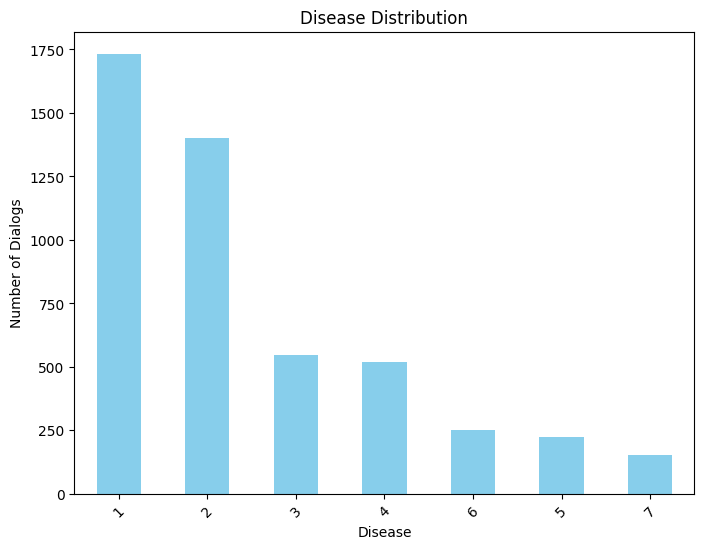

In [36]:
# Load the dataset
df = pd.read_csv('data/raw_data(in) (2).csv', encoding='latin-1')

# Count disease occurrences
disease_counts = df['Disease'].value_counts()

# Plot the bar chart
disease_counts.plot(kind='bar', color='skyblue', figsize=(8, 6))
plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Dialogs")
plt.xticks(rotation=45)
plt.show()


# Word Frequency

C:\Users\feras\AppData\Local\Temp\ipykernel_9240\500108560.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="viridis")


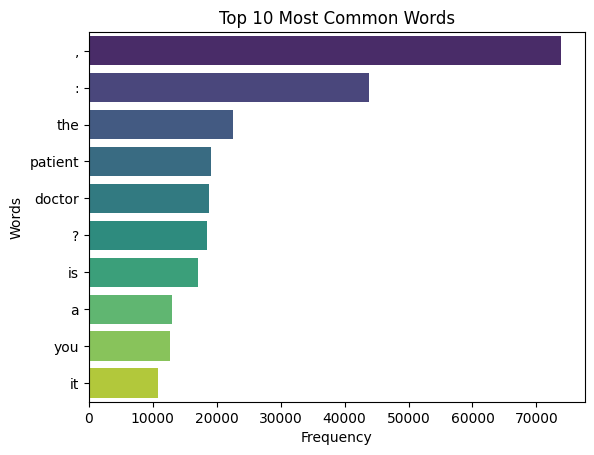

In [47]:
from collections import Counter
from nltk.tokenize import word_tokenize
import seaborn as sns

# Tokenize all dialogs
all_tokens = [word.lower() for dialog in df['Original Dialog'] for word in word_tokenize(dialog)]

# Count word occurrences
word_freq = Counter(all_tokens)

# Get the top 10 most common words
most_common = word_freq.most_common(10)
words, counts = zip(*most_common)

# Plot the bar chart
sns.barplot(x=counts, y=words, palette="viridis")
plt.title("Top 10 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


# model performance

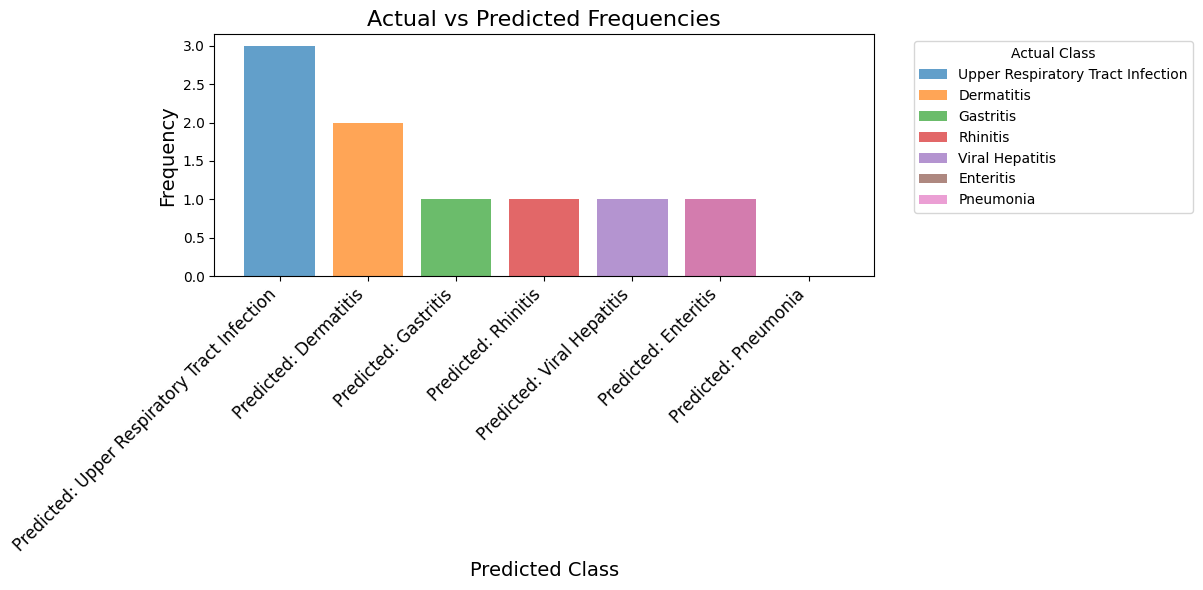

In [51]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Example ground truth and predictions (replace with your actual data)
y_true = [1, 2, 1, 3, 1, 2, 4, 5, 6, 7]
y_pred = [1, 2, 1, 3, 1, 2, 4, 5, 6, 6]

# Class labels
disease_dict = {
    1: "Upper Respiratory Tract Infection",
    2: "Dermatitis",
    3: "Gastritis",
    4: "Rhinitis",
    5: "Viral Hepatitis",
    6: "Enteritis",
    7: "Pneumonia"
}

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Flatten the confusion matrix into a DataFrame for easier plotting
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {label}" for label in disease_dict.values()],
    columns=[f"Predicted: {label}" for label in disease_dict.values()]
)
cm_flat = cm_df.stack().reset_index()
cm_flat.columns = ['Actual', 'Predicted', 'Frequency']

# Plot the bar chart
plt.figure(figsize=(12, 6))
for actual_class in disease_dict.values():
    subset = cm_flat[cm_flat['Actual'] == f"Actual: {actual_class}"]
    plt.bar(
        subset['Predicted'],
        subset['Frequency'],
        label=actual_class,
        alpha=0.7
    )

plt.title("Actual vs Predicted Frequencies", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title="Actual Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from wordcloud import WordCloud

def load_and_prepare_data():
    # Load the data
    df = pd.read_csv('data/raw_data(in) (2).csv')
    return df

def plot_symptom_distribution(df):
    plt.figure(figsize=(15, 8))
    # Count the most common symptoms/keywords
    symptom_counts = Counter(' '.join(df['Original Dialog']).lower().split()).most_common(20)
    symptoms = [item[0] for item in symptom_counts]
    counts = [item[1] for item in symptom_counts]
    
    # Create bar plot
    plt.bar(symptoms, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 20 Most Common Terms in Medical Dialogues')
    plt.xlabel('Terms')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('plots/symptom_distribution.png')
    plt.close()

def plot_dialogue_length_distribution(df):
    plt.figure(figsize=(12, 6))
    # Calculate dialogue lengths
    dialogue_lengths = df['Original Dialog'].str.len()
    
    # Create histogram
    sns.histplot(dialogue_lengths, bins=50)
    plt.title('Distribution of Dialogue Lengths')
    plt.xlabel('Dialogue Length (characters)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('plots/dialogue_length_distribution.png')
    plt.close()

def create_word_cloud(df):
    plt.figure(figsize=(15, 8))
    # Combine all text
    text = ' '.join(df['Original Dialog'])
    
    # Create and generate a word cloud image
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    # Display the word cloud
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Medical Dialogues')
    plt.tight_layout()
    plt.savefig('plots/wordcloud.png')
    plt.close()

def plot_response_patterns(df):
    plt.figure(figsize=(12, 6))
    # Analyze response patterns (e.g., doctor vs patient message lengths)
    df['is_doctor'] = df['Original Dialog'].str.contains('doctor', case=False)
    doctor_lengths = df[df['is_doctor']]['Original Dialog'].str.len()
    patient_lengths = df[~df['is_doctor']]['Original Dialog'].str.len()
    
    # Create box plot
    data = [doctor_lengths, patient_lengths]
    plt.boxplot(data, labels=['Doctor Messages', 'Patient Messages'])
    plt.title('Distribution of Message Lengths: Doctor vs Patient')
    plt.ylabel('Message Length (characters)')
    plt.tight_layout()
    plt.savefig('plots/response_patterns.png')
    plt.close()

def create_all_plots():
    # Create plots directory if it doesn't exist
    import os
    if not os.path.exists('plots'):
        os.makedirs('plots')
    
    # Load data
    df = load_and_prepare_data()
    
    # Generate all plots
    plot_symptom_distribution(df)
    plot_dialogue_length_distribution(df)
    create_word_cloud(df)
    plot_response_patterns(df)
    
    print("All plots have been generated and saved in the 'plots' directory!")

if __name__ == "__main__":
    create_all_plots()
